1. Feladat

In [176]:
# 1.feladat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import colors
data = pd.read_csv("/content/data.csv")
import plotly.express as px
from sklearn.preprocessing import LabelEncoder

2. Feladat

In [177]:
# 2.feladat
print(data.head())
print(data.info())

   Geographical Location (Latitude)  Geographical Location (Longitude)  \
0                         42.867278                        -107.997678   
1                         34.337029                        -104.681197   
2                         34.831615                         -93.134004   
3                         45.463162                        -120.709056   
4                         41.444474                         -99.464055   

  State of Sewage System Sampling Date  Nitrogen (mg/L)  Phosphorus (mg/L)  \
0               Moderate    2015-09-30         5.447159           4.634808   
1                   Good    2020-01-29         9.087964           3.129082   
2               Moderate    2017-09-09         0.485658           4.545678   
3                   Poor    2019-11-12         2.666448           4.090627   
4               Moderate    2016-08-19         8.425540           1.247981   

   Population  
0      923253  
1     1196631  
2      781628  
3      855275  
4     

3. Feladat

In [178]:
# 3.feladat
data['Sampling Date'] = pd.to_datetime(data['Sampling Date'])
print(data.isnull().sum())

Geographical Location (Latitude)     0
Geographical Location (Longitude)    0
State of Sewage System               0
Sampling Date                        0
Nitrogen (mg/L)                      0
Phosphorus (mg/L)                    0
Population                           0
dtype: int64


4. Feladat

a)

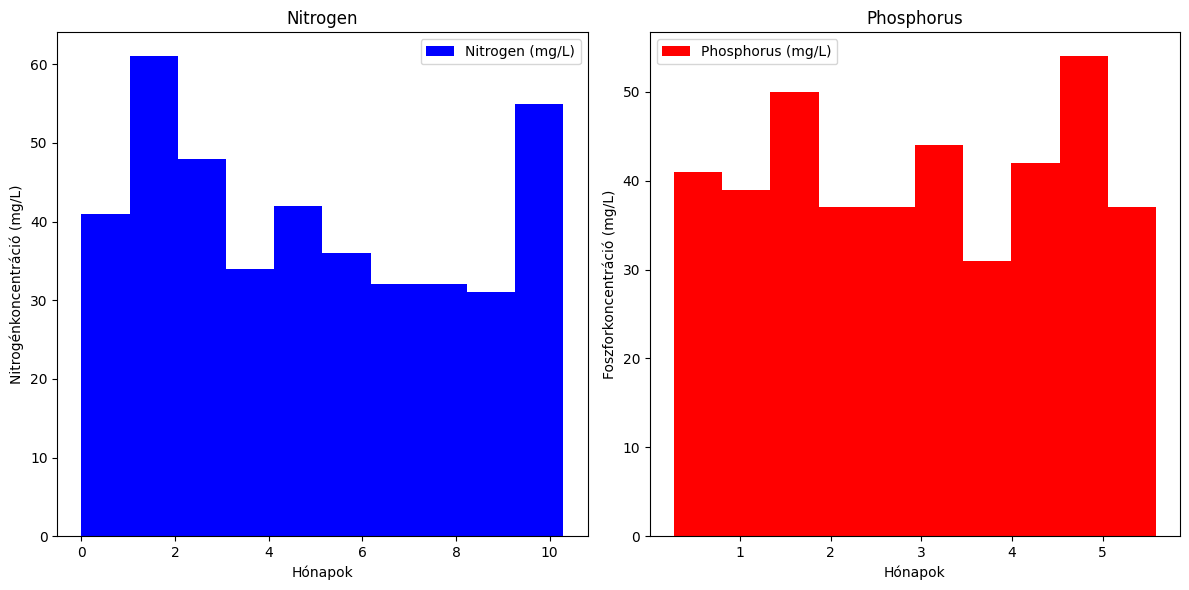

In [179]:
# 4.feladat
# a)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
data['Nitrogen (mg/L)'].plot(kind='hist', color='blue', title='Nitrogen', legend=True)
plt.xlabel('Hónapok')
plt.ylabel('Nitrogénkoncentráció (mg/L)')
plt.subplot(1, 2, 2)
data['Phosphorus (mg/L)'].plot(kind='hist', color='red', title='Phosphorus', legend=True)
plt.xlabel('Hónapok')
plt.ylabel('Foszforkoncentráció (mg/L)')
plt.tight_layout()
plt.show()

b)

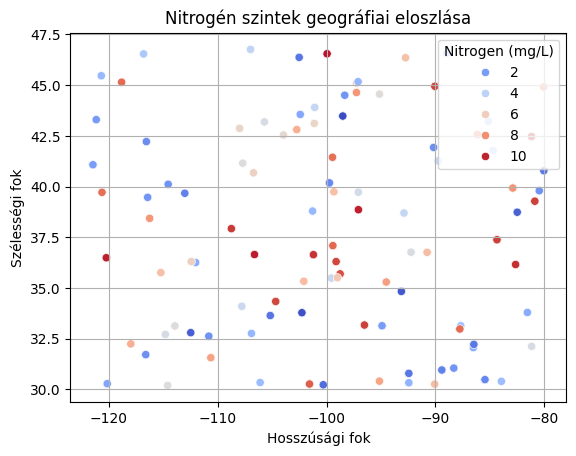

In [180]:
# b)
sns.scatterplot(x=data['Geographical Location (Longitude)'], y=data['Geographical Location (Latitude)'], hue=data['Nitrogen (mg/L)'], palette='coolwarm')
plt.title('Nitrogén szintek geográfiai eloszlása')
plt.xlabel('Hosszúsági fok')
plt.ylabel('Szélességi fok')
plt.grid(True)
plt.show()

c)

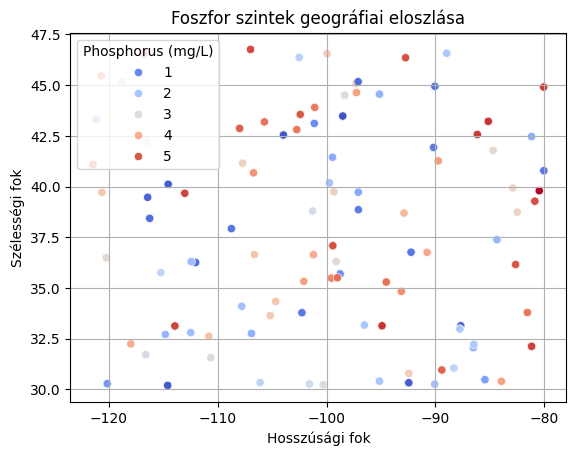

In [181]:
# c)
sns.scatterplot(x=data['Geographical Location (Longitude)'], y=data['Geographical Location (Latitude)'], hue=data['Phosphorus (mg/L)'], palette='coolwarm')
plt.title('Foszfor szintek geográfiai eloszlása')
plt.xlabel('Hosszúsági fok')
plt.ylabel('Szélességi fok')
plt.grid(True)
plt.show()

5. Feladat

In [182]:
# 5.feladat
max_N = round(data['Nitrogen (mg/L)'].max())
print(max_N)
levels = range(max_N+1)
color_dict = dict(zip(levels, list(colors.cnames.values())[0:-1:10]))
fig = px.scatter_mapbox(
    data,
    lat='Geographical Location (Latitude)',
    lon='Geographical Location (Longitude)',
    color='Nitrogen (mg/L)',
    color_discrete_map=color_dict,
    size_max=15,
    zoom=3,
    mapbox_style='open-street-map',
    title='Nitrogénszint mérések',
    hover_data=['State of Sewage System', 'Sampling Date', 'Phosphorus (mg/L)', 'Population']
)
fig.show()

10


6. Feladat

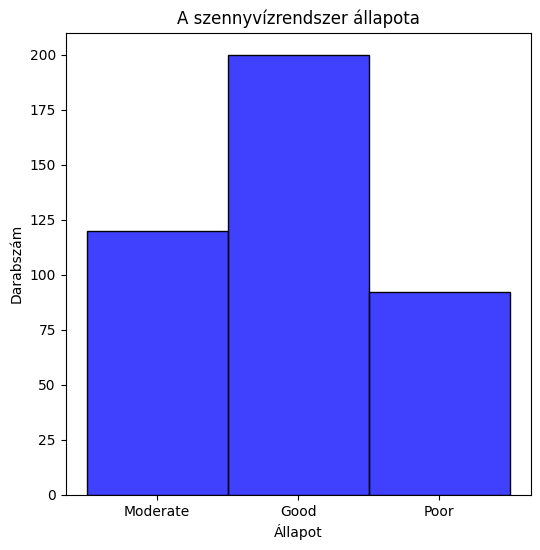

In [183]:
# 6.feladat
plt.figure(figsize=(6, 6))
sns.histplot(data=data,x='State of Sewage System',color='blue',legend=True)
plt.title('A szennyvízrendszer állapota')
plt.xlabel('Állapot')
plt.ylabel('Darabszám')
plt.show()

7. Feladat

   Geographical Location (Latitude)  Geographical Location (Longitude)  \
0                         42.867278                        -107.997678   
1                         34.337029                        -104.681197   
2                         34.831615                         -93.134004   
3                         45.463162                        -120.709056   
4                         41.444474                         -99.464055   

   State of Sewage System Sampling Date  Nitrogen (mg/L)  Phosphorus (mg/L)  \
0                       1    2015-09-30         5.447159           4.634808   
1                       0    2020-01-29         9.087964           3.129082   
2                       1    2017-09-09         0.485658           4.545678   
3                       2    2019-11-12         2.666448           4.090627   
4                       1    2016-08-19         8.425540           1.247981   

   Population        N+P  
0      923253  10.081967  
1     1196631  12.217047  

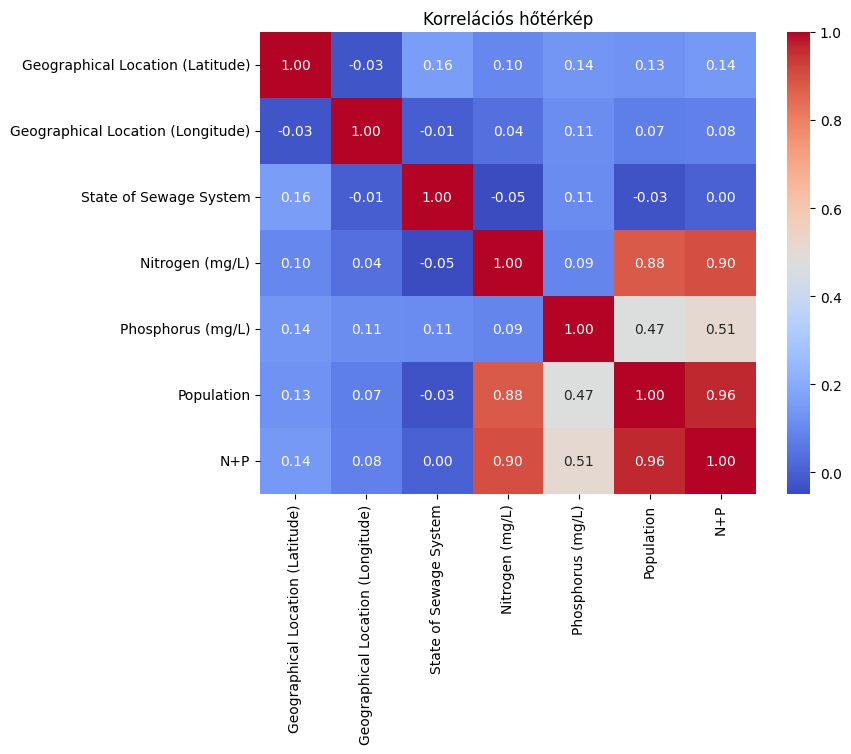

In [184]:
# 7.feladat
# a)
newColumn = []
for i in range(len(data['Nitrogen (mg/L)'])) :
  newColumn.append(data['Nitrogen (mg/L)'][i] + data['Phosphorus (mg/L)'][i])
data['N+P'] = newColumn

#b)
le = LabelEncoder()
le.fit(data['State of Sewage System'])
data['State of Sewage System'] = le.transform(data['State of Sewage System'])
print(data.head()) # Ez az ellenőrzéshez van

#c)
def is_number(value):
    try:
        float(value)
        return True
    except ValueError:
        return False
    except TypeError:
        return False
dataCourse = {}
for key, value in data.items():
    if is_number(value[0]) :
      dataCourse[key] = value
dataCourseDataFrame = pd.DataFrame(dataCourse)

# d)
korrelacio = dataCourseDataFrame.corr(method='pearson')
plt.figure(figsize=(8, 6))
sns.heatmap(korrelacio, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korrelációs hőtérkép')
plt.show()


8. Feladat

In [185]:
# 8.feladat
data.rename(columns={'Geographical Location (Latitude)': 'Lati',
                     'Geographical Location (Longitude)': 'Long',
                     'Sampling Date': 'SDate',
                     'Nitrogen (mg/L)': 'N',
                     'Phosphorus (mg/L)': 'P',
                     'State of Sewage System': 'SWS',}, inplace=True)
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412 entries, 0 to 411
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Lati        412 non-null    float64       
 1   Long        412 non-null    float64       
 2   SWS         412 non-null    int64         
 3   SDate       412 non-null    datetime64[ns]
 4   N           412 non-null    float64       
 5   P           412 non-null    float64       
 6   Population  412 non-null    int64         
 7   N+P         412 non-null    float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 25.9 KB


9. Feladat

In [186]:
# 9.feladat
data.describe()

,Lati,Long,SWS,SDate,N,P,Population,N+P
count,412.000000,412.000000,412.000000,412,412.000000,412.000000,4.120000e+02,412.000000
mean,37.928978,-99.910523,0.737864,2019-02-16 10:08:09.320388352,4.956458,2.941068,9.041799e+05,7.897526
min,30.198108,-121.476341,0.000000,2014-01-02 00:00:00,0.004284,0.272931,2.053480e+05,0.379070
25%,33.138387,-107.997678,0.000000,2016-12-24 18:00:00,2.096088,1.593510,6.752212e+05,4.725642
50%,37.926803,-99.464055,1.000000,2018-12-08 12:00:00,4.821583,2.951642,8.774995e+05,7.935702
75%,42.542049,-90.071769,1.000000,2021-07-02 06:00:00,7.575510,4.327313,1.184369e+06,10.852442
max,46.759853,-80.039258,2.000000,2023-12-25 00:00:00,10.294660,5.586694,1.544160e+06,15.538928
std,5.088459,11.689830,0.800987,NaN,3.097449,1.544422,3.163950e+05,3.585622


10. Feladat

In [187]:
# 10.feladat
data['Q'] = data['N+P'].apply(lambda x: 1 if x < 4 else (3 if x > 10 else 2))
data.head()

,Lati,Long,SWS,SDate,N,P,Population,N+P,Q
0,42.867278,-107.997678,1,2015-09-30,5.447159,4.634808,923253,10.081967,3
1,34.337029,-104.681197,0,2020-01-29,9.087964,3.129082,1196631,12.217047,3
2,34.831615,-93.134004,1,2017-09-09,0.485658,4.545678,781628,5.031337,2
3,45.463162,-120.709056,2,2019-11-12,2.666448,4.090627,855275,6.757075,2
4,41.444474,-99.464055,1,2016-08-19,8.425540,1.247981,1019428,9.673521,2


11. Feladat

In [188]:
# 11.feladat
print(data['Q'].value_counts(ascending=True))

Q
1     77
3    142
2    193
Name: count, dtype: int64


12. Feladat

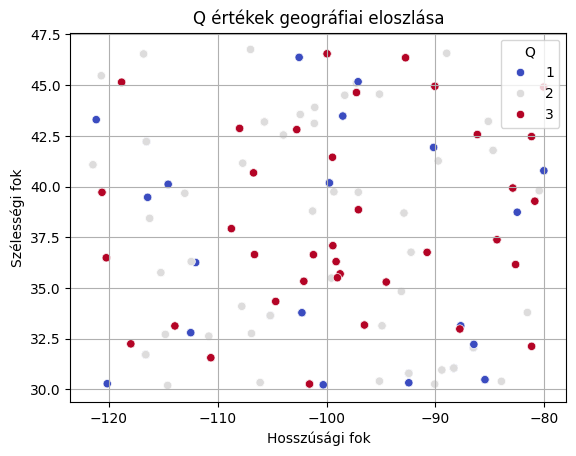

In [189]:
# 12.feladat
sns.scatterplot(x=data['Long'], y=data['Lati'], hue=data['Q'], palette='coolwarm', legend=True)
plt.title('Q értékek geográfiai eloszlása')
plt.xlabel('Hosszúsági fok')
plt.ylabel('Szélességi fok')
plt.grid(True)
plt.show()

13. Feladat

In [190]:
# 13.feladat
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

newDataDict = {}
for key, value in data.items():
    if not key == "SDate" :
      newDataDict[key] = value
newData = pd.DataFrame(newDataDict)
newData.info() # ellenőrzéshez van

x = newData.drop(columns=["SWS"])
y = newData['SWS']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412 entries, 0 to 411
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Lati        412 non-null    float64
 1   Long        412 non-null    float64
 2   SWS         412 non-null    int64  
 3   N           412 non-null    float64
 4   P           412 non-null    float64
 5   Population  412 non-null    int64  
 6   N+P         412 non-null    float64
 7   Q           412 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 25.9 KB


14. Feladat

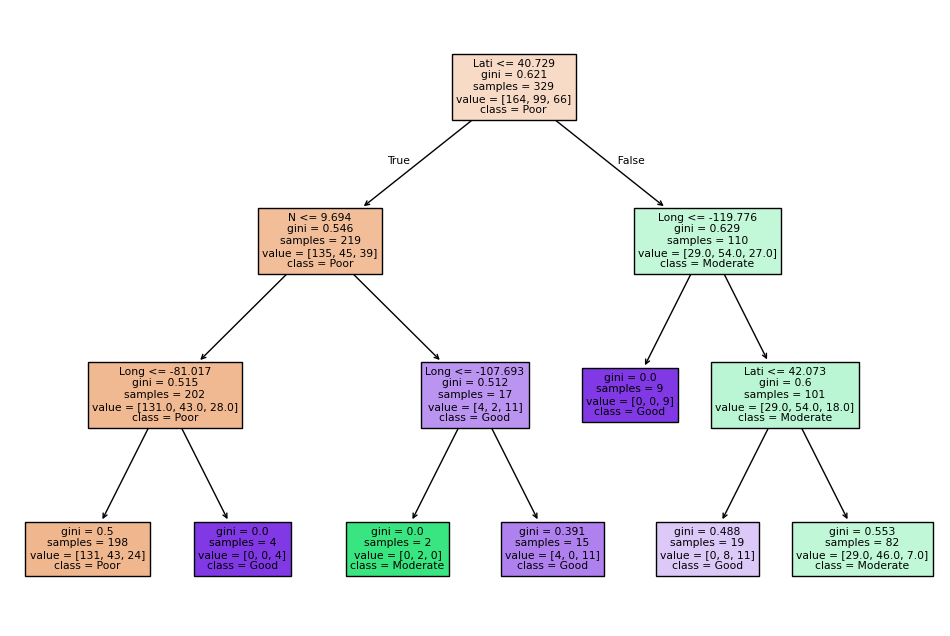

In [191]:
# 14.feladat
# Oszd fel az adatokat tanuló és teszt halmazokra (80%-20% arányban)!
x_learn, x_test, y_learn, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Hozz létre egy döntési fa modellt és tanítsd be a tanuló adatokon!
decision_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
decision_tree.fit(x_learn, y_learn)

# Vizualizáld a döntési fát a Matplotlib segítségével!
plt.figure(figsize=(12, 8))
plot_tree(decision_tree, feature_names=x.columns, class_names=["Poor", "Moderate", "Good"], filled=True)
plt.show()

15. Feladat

In [192]:
# 15.feladat
y_pred = decision_tree.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Pontosság: {accuracy}")

print("Osztályozási Riport:")
print(classification_report(y_test, y_pred))
print("Konfúziós Mátrix:")
print(confusion_matrix(y_test, y_pred))

Pontosság: 0.5301204819277109
Osztályozási Riport:
              precision    recall  f1-score   support

           0       0.48      0.56      0.51        36
           1       0.42      0.52      0.47        21
           2       0.87      0.50      0.63        26

    accuracy                           0.53        83
   macro avg       0.59      0.53      0.54        83
weighted avg       0.59      0.53      0.54        83

Konfúziós Mátrix:
[[20 14  2]
 [10 11  0]
 [12  1 13]]


16. Feladat

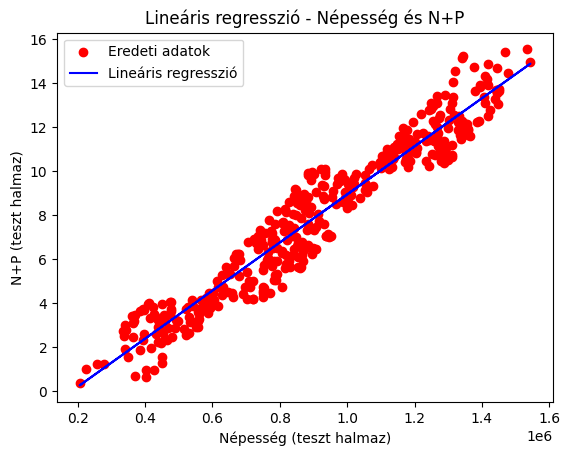

In [193]:
# 16.feladat
x = newData[["Population"]]
y = newData["N+P"]

x_learn, x_test, y_learn, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(x, y)

plt.scatter(newData['Population'], newData['N+P'], color='red', label='Eredeti adatok')
plt.plot(newData['Population'], y_predict, color='blue', label='Lineáris regresszió')
plt.xlabel('Népesség (teszt halmaz)')
plt.ylabel('N+P (teszt halmaz)')
plt.title('Lineáris regresszió - Népesség és N+P')
plt.legend()
plt.show()

17. Feladat

In [194]:
# 17.feladat
y_predict = model.predict(x)
print("Első 5 predikció:", y_predict[:5])
print("Utolsó 5 predikció:", y_predict[-5:])

accuracy = model.score(x_test, y_test)
print("Pontosság:", accuracy)

Első 5 predikció: [ 8.1060591  11.09498761  6.55762798  7.36283403  9.15757092]
Utolsó 5 predikció: [ 6.215437    0.25697567  3.64450015  4.45441846 12.68634293]
Pontosság: 0.9212315691447786
